# Precision-Recall Curves for Barcode Calling Tools

This notebook generates precision-recall curves for parameter sweep analysis of three barcode calling tools:
- **QUIK**: Testing different k-mer strategies and rejection thresholds
- **RandomBarcodes**: Testing different Ntriage levels and Nthresh values
- **Columba**: Testing different identity thresholds

The analysis covers two barcode lengths: **28 nt** and **36 nt**.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 1. Load Data

In [2]:
# Define base directory (relative to notebook location)
BASE_DIR = Path("../results/parameter_sweep")

def load_precision_reports_for_length(base_dir, barcode_length):
    """
    Scan all tool sweep directories and load precision_summary.csv files.
    Returns a combined DataFrame with all results for this barcode length.
    
    New flat structure (after publishDir fix):
    results_XX_nt/tool_sweep/PARAM_DIR/sample_precision_summary.csv
    
    Example:
    results_28nt/quik_sweep/4mer_r5/QUIK_28nt_4mer_r5_precision_summary.csv
    results_28nt/columba_sweep/I77/Columba28_I77_precision_summary.csv
    """
    results_dir = base_dir / f"results_{barcode_length}nt"
    all_data = []
    
    for sweep_type in ['randombarcodes_sweep', 'quik_sweep', 'columba_sweep']:
        sweep_dir = results_dir / sweep_type
        if not sweep_dir.exists():
            continue
        
        # Find all precision_summary.csv files directly in parameter directories
        for csv_file in sweep_dir.rglob('*precision_summary.csv'):
            try:
                # Read CSV file
                df_metrics = pd.read_csv(csv_file)
                metrics = {}
                
                # Extract precision and recall from CSV
                for _, row in df_metrics.iterrows():
                    metric_name = row['metric']
                    value = row['value']
                    
                    if metric_name == 'precision_percent':
                        metrics['precision'] = value
                    elif metric_name == 'recall_percent':
                        metrics['recall'] = value
                    elif metric_name == 'accuracy_percent':
                        metrics['accuracy'] = value
                
                # Calculate F1 score
                if 'precision' in metrics and 'recall' in metrics:
                    p = metrics['precision']
                    r = metrics['recall']
                    if p + r > 0:
                        metrics['f1_score'] = 2 * (p * r) / (p + r)
                    else:
                        metrics['f1_score'] = 0.0
                
                # Get parameter directory (parent of CSV file)
                # With flat structure: csv_file is in PARAM_DIR directly
                param_dir = csv_file.parent.name
                
                # Get sample name from filename
                sample_name = csv_file.stem.replace('_precision_summary', '')
                metrics['sample_id'] = sample_name
                
                # Add tool info and parse parameters
                if 'randombarcodes' in str(sweep_dir):
                    metrics['tool'] = 'RandomBarcodes'
                    # Parse t100_n9 format
                    if '_t' in param_dir and '_n' in param_dir:
                        metrics['ntriage'] = int(param_dir.split('_t')[1].split('_')[0])
                        metrics['nthresh'] = int(param_dir.split('_n')[1])
                        metrics['threshold'] = metrics['nthresh']
                elif 'quik' in str(sweep_dir):
                    metrics['tool'] = 'QUIK'
                    # Parse 4mer_r8 format
                    if 'mer_r' in param_dir:
                        strategy_part = param_dir.split('_r')[0]
                        metrics['strategy'] = strategy_part + '_mer' if not strategy_part.endswith('mer') else strategy_part
                        metrics['rejection_threshold'] = int(param_dir.split('_r')[1])
                        metrics['threshold'] = metrics['rejection_threshold']
                elif 'columba' in str(sweep_dir):
                    metrics['tool'] = 'Columba'
                    # Parse I80 format
                    if param_dir.startswith('I'):
                        metrics['identity_threshold'] = int(param_dir[1:])
                        metrics['threshold'] = metrics['identity_threshold']
                
                metrics['barcode_length'] = barcode_length
                all_data.append(metrics)
            except Exception as e:
                print(f"Warning: Could not parse {csv_file}: {e}")
                import traceback
                traceback.print_exc()
                continue
    
    return pd.DataFrame(all_data) if all_data else pd.DataFrame()

# Load data for both barcode lengths
print(f"Loading data from: {BASE_DIR.resolve()}")

df_28nt = load_precision_reports_for_length(BASE_DIR, 28)
if not df_28nt.empty:
    print(f"✓ Loaded 28nt data: {len(df_28nt)} samples")
    print(f"  Tools: {df_28nt['tool'].unique().tolist()}")
    print(f"  Columns: {df_28nt.columns.tolist()}")
else:
    print(f"✗ No 28nt data found")

df_36nt = load_precision_reports_for_length(BASE_DIR, 36)
if not df_36nt.empty:
    print(f"✓ Loaded 36nt data: {len(df_36nt)} samples")
    print(f"  Tools: {df_36nt['tool'].unique().tolist()}")
else:
    print(f"✗ No 36nt data found")

# Combine datasets
df_all = pd.concat([df_28nt, df_36nt], ignore_index=True)
print(f"\n✓ Combined dataset: {len(df_all)} samples")
if not df_all.empty:
    print(f"  Has precision/recall: {('precision' in df_all.columns) and ('recall' in df_all.columns)}")

Loading data from: /kyukon/scratch/gent/vo/000/gvo00027/vsc44685/barcalling_review/BarCall_benchmark/results/parameter_sweep
✓ Loaded 28nt data: 3 samples
  Tools: ['QUIK', 'Columba']
✓ Loaded 36nt data: 5 samples
  Tools: ['QUIK', 'Columba']

✓ Combined dataset: 8 samples


## 2. Data Preview

In [3]:
# Preview data structure
if df_all is not None:
    print("Data shape:", df_all.shape)
    print("\nColumns:", df_all.columns.tolist())
    print("\nFirst few rows:")
    display(df_all.head())
    
    print("\nData summary by tool and barcode length:")
    summary = df_all.groupby(['tool', 'barcode_length']).size().reset_index(name='count')
    display(summary)

Data shape: (8, 2)

Columns: ['tool', 'barcode_length']

First few rows:


,tool,barcode_length
0,QUIK,28
1,Columba,28
2,Columba,28
3,QUIK,36
4,QUIK,36



Data summary by tool and barcode length:


,tool,barcode_length,count
0,Columba,28,2
1,Columba,36,3
2,QUIK,28,1
3,QUIK,36,2


## 3. Precision-Recall Curves (2×3 Layout)

Create a 2-row × 3-column layout:
- **Rows**: Barcode lengths (28 nt, 36 nt)
- **Columns**: Tools (QUIK, RandomBarcodes, Columba)

### Tool-specific encoding:
- **QUIK**: Color = k-mer strategy, Points = rejection threshold (r)
- **RandomBarcodes**: Color = Ntriage level, Points = Nthresh
- **Columba**: Single curve with points = identity threshold (-I)

In [4]:
df_all.head()

,tool,barcode_length
0,QUIK,28
1,Columba,28
2,Columba,28
3,QUIK,36
4,QUIK,36


KeyError: 'strategy'

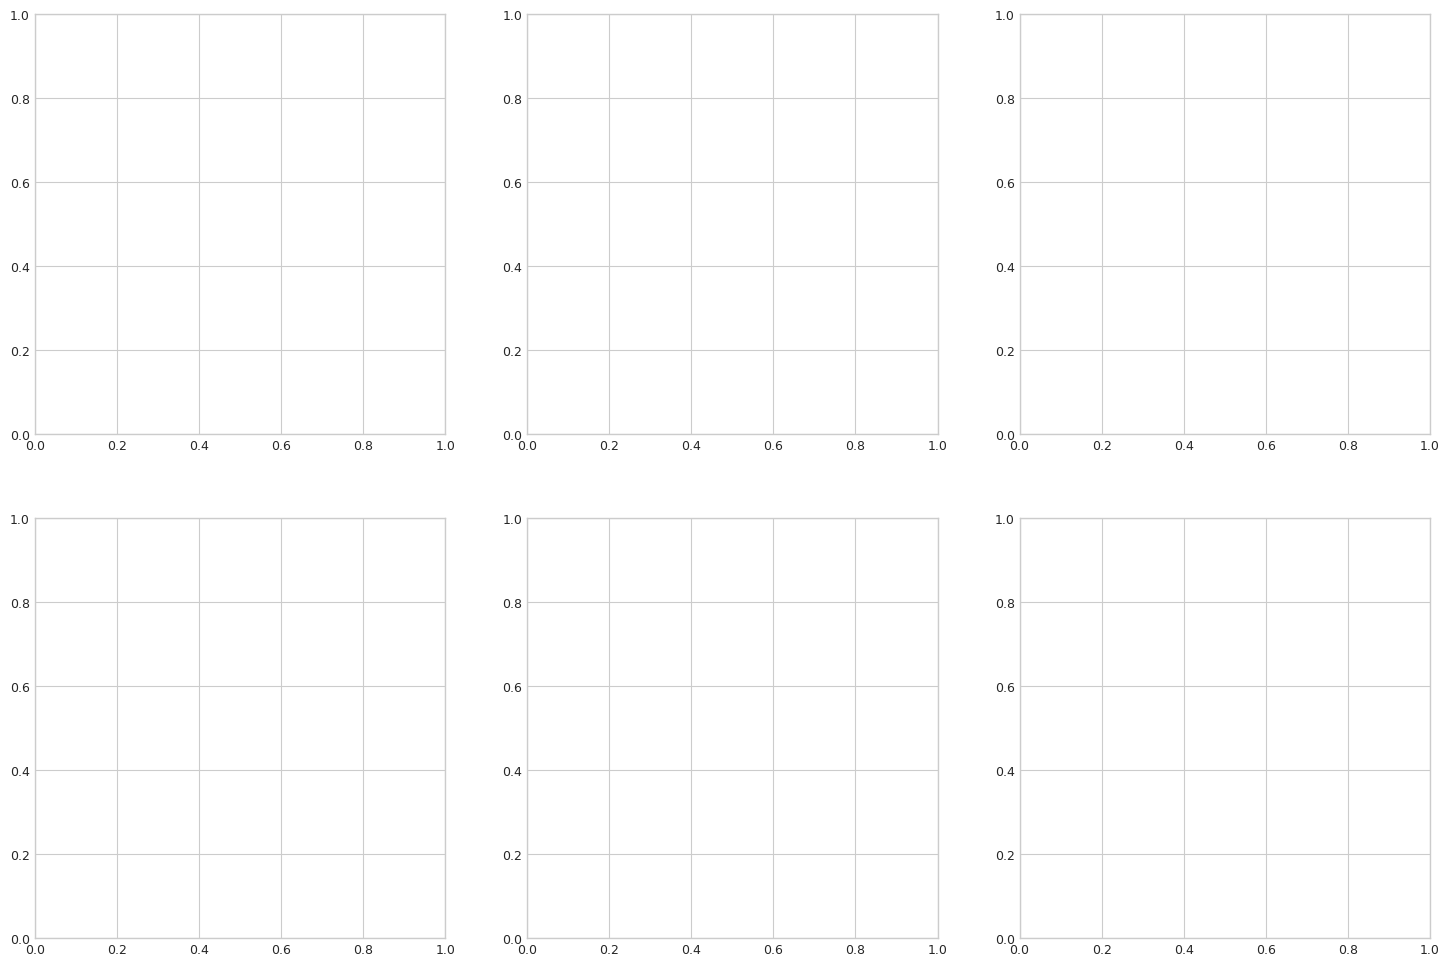

In [ ]:
if df_all is not None and not df_all.empty and 'precision' in df_all.columns and 'recall' in df_all.columns:
    # Create figure with 2 rows and 3 columns
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Define color palettes for each tool
    quik_palette = sns.color_palette("Set2", n_colors=10)
    rb_palette = sns.color_palette("Set2", n_colors=10)
    columba_color = '#2ca02c'
    
    # Define marker styles for thresholds
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'X', 'P']
    
    # Iterate over barcode lengths (rows)
    barcode_lengths = sorted(df_all['barcode_length'].unique())
    tools = ['QUIK', 'RandomBarcodes', 'Columba']
    
    for row_idx, barcode_len in enumerate(barcode_lengths):
        df_length = df_all[df_all['barcode_length'] == barcode_len]
        
        for col_idx, tool in enumerate(tools):
            ax = axes[row_idx, col_idx]
            df_tool = df_length[df_length['tool'] == tool].copy()
            
            if len(df_tool) == 0:
                ax.text(0.5, 0.5, f'No data for {tool}\n{barcode_len}nt', 
                       ha='center', va='center', fontsize=12)
                ax.set_xlim(0, 100)
                ax.set_ylim(0, 100)
                ax.set_xlabel('Recall (%)', fontweight='bold')
                ax.set_ylabel('Precision (%)', fontweight='bold')
                if row_idx == 0:
                    ax.set_title(f'{tool}', fontsize=14, fontweight='bold', pad=10)
                if col_idx == 0:
                    ax.text(-0.15, 0.5, f'{barcode_len} nt', 
                           transform=ax.transAxes, fontsize=14, fontweight='bold',
                           ha='center', va='center', rotation=90)
                continue
            
            # QUIK: Different curves for different strategies
            if tool == 'QUIK' and 'strategy' in df_tool.columns:
                strategies = sorted(df_tool['strategy'].dropna().unique())
                for strat_idx, strategy in enumerate(strategies):
                    df_strat = df_tool[df_tool['strategy'] == strategy].sort_values('rejection_threshold')
                    
                    if len(df_strat) > 0:
                        color = quik_palette[strat_idx % len(quik_palette)]
                        
                        # Plot line
                        ax.plot(df_strat['recall'], df_strat['precision'], 
                               '-', color=color, linewidth=2, alpha=0.6)
                        
                        # Plot points with labels
                        for _, row in df_strat.iterrows():
                            r_val = row['rejection_threshold']
                            ax.plot(row['recall'], row['precision'], 
                                   marker='o', color=color, markersize=5, 
                                   markeredgecolor='black', markeredgewidth=0.5)
                            ax.text(row['recall']+0.8, row['precision']+0.5, f'{int(r_val)}', 
                                   fontsize=7, ha='left', va='bottom')
                        
                        # Add legend entry
                        ax.plot([], [], '-o', color=color, label=strategy, linewidth=2)
            
            # RandomBarcodes: Different curves for different Ntriage levels
            elif tool == 'RandomBarcodes' and 'ntriage' in df_tool.columns:
                ntriage_levels = sorted(df_tool['ntriage'].dropna().unique())
                for ntriage_idx, ntriage in enumerate(ntriage_levels):
                    df_ntriage = df_tool[df_tool['ntriage'] == ntriage].sort_values('nthresh')
                    
                    if len(df_ntriage) > 0:
                        color = rb_palette[ntriage_idx % len(rb_palette)]
                        
                        # Plot line
                        ax.plot(df_ntriage['recall'], df_ntriage['precision'], 
                               '-', color=color, linewidth=2, alpha=0.6)
                        
                        # Plot points with labels
                        for _, row in df_ntriage.iterrows():
                            nthresh_val = row['nthresh']
                            ax.plot(row['recall'], row['precision'], 
                                   marker='s', color=color, markersize=5,
                                   markeredgecolor='black', markeredgewidth=0.5)
                            ax.text(row['recall']+0.8, row['precision']+0.5, f'{int(nthresh_val)}', 
                                   fontsize=7, ha='left', va='bottom')
                        
                        # Add legend entry
                        ax.plot([], [], '-s', color=color, 
                               label=f'Ntriage={int(ntriage)}', linewidth=2)
            
            # Columba: Single curve with identity threshold
            elif tool == 'Columba' and 'identity_threshold' in df_tool.columns:
                df_columba = df_tool.sort_values('identity_threshold')
                
                if len(df_columba) > 0:
                    # Plot line
                    ax.plot(df_columba['recall'], df_columba['precision'], 
                           '-', color=columba_color, linewidth=2, alpha=0.6)
                    
                    # Plot points with labels
                    for _, row in df_columba.iterrows():
                        i_val = row['identity_threshold']
                        ax.plot(row['recall'], row['precision'], 
                               marker='^', color=columba_color, markersize=5,
                               markeredgecolor='black', markeredgewidth=0.5)
                        ax.text(row['recall']+0.8, row['precision']+0.5, f'{int(i_val)}', 
                               fontsize=7, ha='left', va='bottom')
            
            # Formatting
            ax.set_xlabel('Recall (%)', fontweight='bold')
            ax.set_ylabel('Precision (%)', fontweight='bold')
            
            # Title for top row only
            if row_idx == 0:
                ax.set_title(f'{tool}', fontsize=14, fontweight='bold', pad=10)
            
            # Add barcode length label on left side
            if col_idx == 0:
                ax.text(-0.15, 0.5, f'{barcode_len} nt', 
                       transform=ax.transAxes, fontsize=14, fontweight='bold',
                       ha='center', va='center', rotation=90)
            
            ax.grid(True, alpha=0.3, linestyle='--')
            ax.set_xlim(20, 100)
            ax.set_ylim(70, 105)
            
            # Add legend to panels with data
            if len(df_tool) > 0 and tool in ['QUIK', 'RandomBarcodes']:
                handles, labels = ax.get_legend_handles_labels()
                if handles:  # Only add legend if there are entries
                    ax.legend(loc='lower left', framealpha=0.9, fontsize=8)
    
    plt.tight_layout()
    
    # Save figure
    output_dir = Path('figures')
    output_dir.mkdir(exist_ok=True)
    output_file = output_dir / 'precision_recall_curves_2x3.pdf'
    #plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\n✓ Figure saved to: {output_file}")
    
    plt.show()
else:
    print("ERROR: No data available for plotting or missing precision/recall columns")
    if df_all is not None and not df_all.empty:
        print(f"Available columns: {df_all.columns.tolist()}")

## 4. Summary Statistics

In [6]:
if df_all is not None and not df_all.empty and 'precision' in df_all.columns:
    print("="*80)
    print("SUMMARY STATISTICS BY TOOL AND BARCODE LENGTH")
    print("="*80)
    
    tools = sorted(df_all['tool'].unique())
    barcode_lengths = sorted(df_all['barcode_length'].unique())
    
    for tool in tools:
        print(f"\n{tool}:")
        print("-"*80)
        for barcode_len in barcode_lengths:
            df_subset = df_all[(df_all['tool'] == tool) & (df_all['barcode_length'] == barcode_len)]
            
            if len(df_subset) > 0:
                print(f"\n  {barcode_len} nt barcodes ({len(df_subset)} configurations):")
                print(f"    Precision: {df_subset['precision'].mean():.2f}% (±{df_subset['precision'].std():.2f})")
                print(f"    Recall:    {df_subset['recall'].mean():.2f}% (±{df_subset['recall'].std():.2f})")
                print(f"    F1-Score:  {df_subset['f1_score'].mean():.2f} (±{df_subset['f1_score'].std():.2f})")
                
                # Best configuration
                best = df_subset.loc[df_subset['f1_score'].idxmax()]
                print(f"    Best F1:   {best['f1_score']:.2f} (P={best['precision']:.2f}%, R={best['recall']:.2f}%)")
                if 'sample_id' in best:
                    print(f"               Config: {best['sample_id']}")
else:
    print("ERROR: No data available or missing required columns for statistics")

SUMMARY STATISTICS BY TOOL AND BARCODE LENGTH

QUIK:
--------------------------------------------------------------------------------

  28 nt barcodes (18 configurations):
    Precision: 93.08% (±8.67)
    Recall:    64.57% (±12.41)
    F1-Score:  74.99 (±8.02)
    Best F1:   83.69 (P=95.75%, R=74.33%)
               Config: QUIK_4mer_r8

  36 nt barcodes (18 configurations):
    Precision: 99.63% (±0.68)
    Recall:    83.49% (±14.04)
    F1-Score:  90.17 (±8.96)
    Best F1:   97.72 (P=99.63%, R=95.88%)
               Config: QUIK_4mer_r9

RandomBarcodes:
--------------------------------------------------------------------------------

  28 nt barcodes (24 configurations):
    Precision: 93.68% (±6.98)
    Recall:    65.99% (±17.42)
    F1-Score:  75.38 (±11.57)
    Best F1:   85.00 (P=95.13%, R=76.83%)
               Config: RB_t100_n8

  36 nt barcodes (15 configurations):
    Precision: 99.93% (±0.10)
    Recall:    52.75% (±17.24)
    F1-Score:  67.45 (±15.15)
    Best F1:   86.